# Proyek Machine Learning Pemula: Beverage Sales Dataset 
- **Nama:** Audy Nadira Ramadanti
- **Email:** audynadiraramdanti@gmail.com
- **ID Dicoding:** audy_nadira_ramadanti_zWZ9

# **1. Import Library**

In [1]:
#Type your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


Sebelum memulai pemrosesan data, saya memerlukan beberapa library yang membantu dalam pengolahan, analisis, dan visualisasi data, serta penerapan algoritma clustering. Berikut adalah penjelasan singkat mengenai masing-masing library dan fungsi yang diimpor:

**1. `pandas` (`import pandas as pd`)**  
   - Digunakan untuk **manipulasi dan analisis data**.  
   - Memiliki struktur data **DataFrame** dan **Series** yang memudahkan operasi seperti membaca, menulis, menggabungkan, dan memfilter data.

**2. `NumPy` (`import numpy as np`)**  
   - Menyediakan **array multidimensi** yang efisien dan berbagai fungsi matematika untuk perhitungan numerik.  
   - Sering digunakan bersama Pandas untuk melakukan operasi numerik yang lebih kompleks.

**3. `matplotlib.pyplot` (`import matplotlib.pyplot as plt`)**  
   - Memungkinkan pembuatan **grafik dan visualisasi data** dasar, seperti plot garis, histogram, dan scatter plot.  
   - Sangat fleksibel dan dapat dikustomisasi untuk berbagai jenis visualisasi.

**4. `seaborn` (`import seaborn as sns`)**  
   - Memperluas Matplotlib dengan **tampilan visualisasi statistik** yang lebih menarik dan mudah dipahami.  
   - Memiliki fungsi bawaan untuk membuat plot seperti heatmap, boxplot, dan pairplot secara lebih sederhana.

**5. `OneHotEncoder` (`from sklearn.preprocessing import OneHotEncoder`)**  
   - Digunakan untuk **mengubah (encode) fitur kategorikal** menjadi variabel dummy (kolom biner).  
   - Sangat berguna ketika fitur kategorikal tidak bersifat ordinal dan memiliki beberapa kategori unik.

**6. `LabelEncoder` (`from sklearn.preprocessing import LabelEncoder`)**  
   - Mengubah nilai kategori menjadi **label numerik** (misalnya 0, 1, 2, dst.).  
   - Cocok untuk kasus di mana kolom kategorikal bisa diwakili oleh integer label tanpa perlu menambah banyak kolom baru.

**7. `MinMaxScaler` (`from sklearn.preprocessing import MinMaxScaler`)**  
   - Digunakan untuk **menormalisasi** atau **menskalakan** data numerik ke dalam rentang tertentu, biasanya [0, 1].  
   - Membantu algoritma *machine learning* yang sensitif terhadap skala data agar kinerjanya lebih optimal.

**8. `train_test_split` (`from sklearn.model_selection import train_test_split`)**  
   - Memudahkan **pembagian dataset** menjadi **data latih** dan **data uji** secara acak.  
   - Membantu dalam memvalidasi model dengan mengecek performa pada data yang belum pernah dilihat sebelumnya.

**9. `classification_report` (`from sklearn.metrics import classification_report`)**  
   - Memberikan **ringkasan metrik evaluasi** untuk tugas klasifikasi, seperti **precision**, **recall**, dan **f1-score**.  
   - Memudahkan kita untuk melihat performa model di setiap kelas secara rinci.

**10. `accuracy_score` (`from sklearn.metrics import accuracy_score`)**  
   - Menghitung **akurasi** model klasifikasi, yaitu persentase prediksi benar dari keseluruhan data uji.  
   - Salah satu metrik umum untuk menilai performa model klasifikasi.

**11. `LogisticRegression` (`from sklearn.linear_model import LogisticRegression`)**  
   - Model klasifikasi yang menggunakan **regresi logistik** untuk memprediksi kelas (0/1).  
   - Sering digunakan sebagai baseline karena sederhana namun cukup efektif.

**12. `RandomForestClassifier` (`from sklearn.ensemble import RandomForestClassifier`)**  
   - Model **ensemble** berbasis banyak *decision tree* yang dikombinasikan secara acak (random) untuk meningkatkan akurasi dan mengurangi *overfitting*.

**13. `xgboost` (`import xgboost as xgb`)**  
   - Model **gradient boosting** yang efisien dan seringkali memberikan performa tinggi dalam berbagai kompetisi data.  
   - Mampu menangani data dengan jumlah fitur besar dan mendukung *regularization* yang baik.

**14. `GridSearchCV` (`from sklearn.model_selection import GridSearchCV`)**  
   - Melakukan **pencarian sistematis** atas kombinasi parameter yang ditentukan untuk menemukan **hyperparameter** optimal.  
   - Menggunakan teknik **cross-validation** dalam proses pencariannya.

**15. `RandomizedSearchCV` (`from sklearn.model_selection import RandomizedSearchCV`)**  
   - Alternatif yang lebih **efisien** daripada GridSearchCV dengan melakukan **pencarian acak** pada ruang parameter.  
   - Cocok untuk ruang parameter yang besar atau waktu komputasi yang terbatas.

**16. `learning_curve` (`from sklearn.model_selection import learning_curve`)**  
   - Digunakan untuk **membuat kurva pembelajaran** yang menunjukkan bagaimana kinerja model berubah dengan bertambahnya data latih.  
   - Membantu mendeteksi apakah model mengalami *overfitting* atau *underfitting*.

**17. `cross_val_score` (`from sklearn.model_selection import cross_val_score`)**  
   - Memungkinkan kita melakukan **evaluasi model** dengan *k-fold cross-validation* secara mudah.  
   - Menghasilkan skor performa di setiap fold, sehingga kita bisa melihat **variabilitas** dan **rata-rata** performa model.

**18. `MLPClassifier` (`from sklearn.neural_network import MLPClassifier`)**  
   - Model **Neural Network** (Multi-Layer Perceptron) dari scikit-learn.  
   - Mampu mempelajari hubungan non-linear dalam data melalui beberapa lapisan tersembunyi.

# **2. Memuat Dataset dari Hasil Clustering**

In [2]:
#Type your code here

data = pd.read_csv("data/Data_Clustering.csv")

Karena sebelumnya kita sudah mendapatkan **label** dari pemodelan klasterisasi dan telah menyimpannya dalam file **CSV** (`Data_Clustering.csv`), selanjutnya saya akan **menggunakannya untuk proses klasifikasi**. Hal ini saya lakukan dengan **menjadikan kolom hasil klasterisasi sebagai target (label)** dalam pendekatan **supervised learning**. Dengan demikian, kita dapat membangun model klasifikasi (misalnya Decision Tree, Random Forest, atau Logistic Regression) yang mampu memprediksi **segmen pelanggan** (label klaster) untuk data baru berdasarkan fitur-fitur yang tersedia.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       10000 non-null  object 
 1   Order_ID          10000 non-null  object 
 2   Unit_Price        10000 non-null  float64
 3   Total_Price       10000 non-null  float64
 4   Quantity          10000 non-null  float64
 5   Discount          10000 non-null  float64
 6   Region            10000 non-null  object 
 7   Cluster           10000 non-null  int64  
 8   Customer_Type     10000 non-null  object 
 9   Customer_Segment  10000 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


Sebelum mulai memproses data, langkah pertama yang saya lakukan adalah **memeriksa struktur dataset** dengan menggunakan `data.info()`. Dari hasil tersebut, dapat dilihat:

- **Jumlah baris**: 10.000  
- **Jumlah kolom**: 10  
- **Tipe data**:  
  - 5 kolom bertipe *object* (`Customer_ID`, `Order_ID`, `Region`, `Customer_Type`, `Customer_Segment`)  
  - 4 kolom bertipe *float64* (`Unit_Price`, `Total_Price`, `Quantity`, `Discount`)  
  - 1 kolom bertipe *int64* (`Cluster`)  
- **Tidak ada missing values** (semua kolom memiliki 10.000 non-null entries).  
- **Penggunaan memori**: sekitar 781.4 KB.

Dengan mengetahui struktur data seperti ini, kita bisa merencanakan **langkah preprocessing** selanjutnya, misalnya:
- Mengecek apakah kolom bertipe *object* perlu diubah ke tipe kategori atau tipe numerik tertentu.  
- Melakukan *feature engineering* jika diperlukan (contoh: menghitung metrik baru dari `Unit_Price` dan `Quantity`, atau menganalisis segmen pelanggan berdasarkan `Customer_Type`).  
- Menentukan metode yang tepat untuk menangani data jika ada anomali (misalnya nilai ekstrem pada `Discount` atau `Total_Price`).  

Langkah awal ini penting agar kita memahami karakteristik dasar dataset sebelum melakukan analisis lebih lanjut.

# **3. Pre-Processing Data**

In [4]:
#Type your code here

data = data.drop(columns=["Customer_ID", "Order_ID"])

Karena menurut saya kolom **`Customer_ID`** dan **`Order_ID`** tidak memberikan informasi yang relevan untuk keperluan pemodelan klasifikasi (umumnya hanya bersifat *identifier* yang unik untuk setiap entitas), saya memutuskan untuk menghapusnya. Proses penghapusan ini dilakukan dengan:

```python
data = data.drop(columns=["Customer_ID", "Order_ID"])
```

Tujuannya adalah untuk menyederhanakan dataset sehingga hanya kolom yang berpotensi memberikan *insight* prediktif yang tersisa. Langkah ini juga membantu **mencegah kebocoran data** (data leakage) serta mengurangi kebisingan (*noise*) yang dapat mempengaruhi kinerja model.

In [5]:
le = LabelEncoder()
data['Region'] = le.fit_transform(data['Region'])

Selanjutnya, saya melakukan **encoding** pada data bersifat kategorikal, khususnya pada fitur **`Region`**. Karena fitur ini memiliki nilai unik yang sangat banyak, saya menggunakan **`LabelEncoder`** agar setiap kategori dapat diubah menjadi representasi numerik. Dengan demikian, model *machine learning* yang umumnya hanya menerima input numerik akan lebih mudah mengolah variabel **`Region`** tanpa kehilangan informasi kategorikalnya.

In [6]:
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' untuk menghindari multikolinearitas
encoded_region = encoder.fit_transform(data[['Customer_Type']])

region_df = pd.DataFrame(encoded_region, columns=encoder.get_feature_names_out(['Customer_Type']))

data = data.drop(columns=['Customer_Type']).reset_index(drop=True)
data = pd.concat([data, region_df], axis=1)


Selanjutnya, saya menerapkan **One Hot Encoding** pada fitur **`Customer_Type`**. Meskipun fitur ini hanya memiliki 2 kategori unik, proses ini tetap diperlukan agar setiap kategori dapat diwakili oleh nilai biner (0 atau 1) yang mudah dipahami oleh model. Selain itu, saya menggunakan parameter **`drop='first'`** untuk menghindari masalah *multicollinearity* atau *dummy variable trap*, di mana salah satu kolom akan menjadi *baseline* dan tidak perlu ditampilkan secara eksplisit. 

Dengan demikian, setelah proses ini, dataset akan memiliki kolom baru yang mewakili kategori **`Customer_Type`** secara numerik, sementara kolom aslinya sudah dihapus agar tidak menimbulkan redundansi.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unit_Price         10000 non-null  float64
 1   Total_Price        10000 non-null  float64
 2   Quantity           10000 non-null  float64
 3   Discount           10000 non-null  float64
 4   Region             10000 non-null  int32  
 5   Cluster            10000 non-null  int64  
 6   Customer_Segment   10000 non-null  object 
 7   Customer_Type_B2C  10000 non-null  float64
dtypes: float64(5), int32(1), int64(1), object(1)
memory usage: 586.1+ KB


Setelah proses *encoding*, saya kembali memeriksa struktur data menggunakan `data.info()`. Hasilnya menunjukkan bahwa:

- Kolom **`Region`** kini sudah bertipe numerik (`int32`) berkat proses *label encoding*.  
- Kolom **`Customer_Type_B2C`** juga telah ditambahkan sebagai kolom baru dengan tipe *float64*, menandakan bahwa *one-hot encoding* berhasil dilakukan.  
- Kolom **`Customer_Segment`** masih bertipe *object*, sehingga jika dibutuhkan, kita bisa melakukan proses encoding lebih lanjut di kolom tersebut.

Dengan demikian, data yang bersifat kategorikal telah berubah menjadi numerik sesuai yang diharapkan, dan kita siap melanjutkan proses *preprocessing* atau analisis/pemodelan selanjutnya.

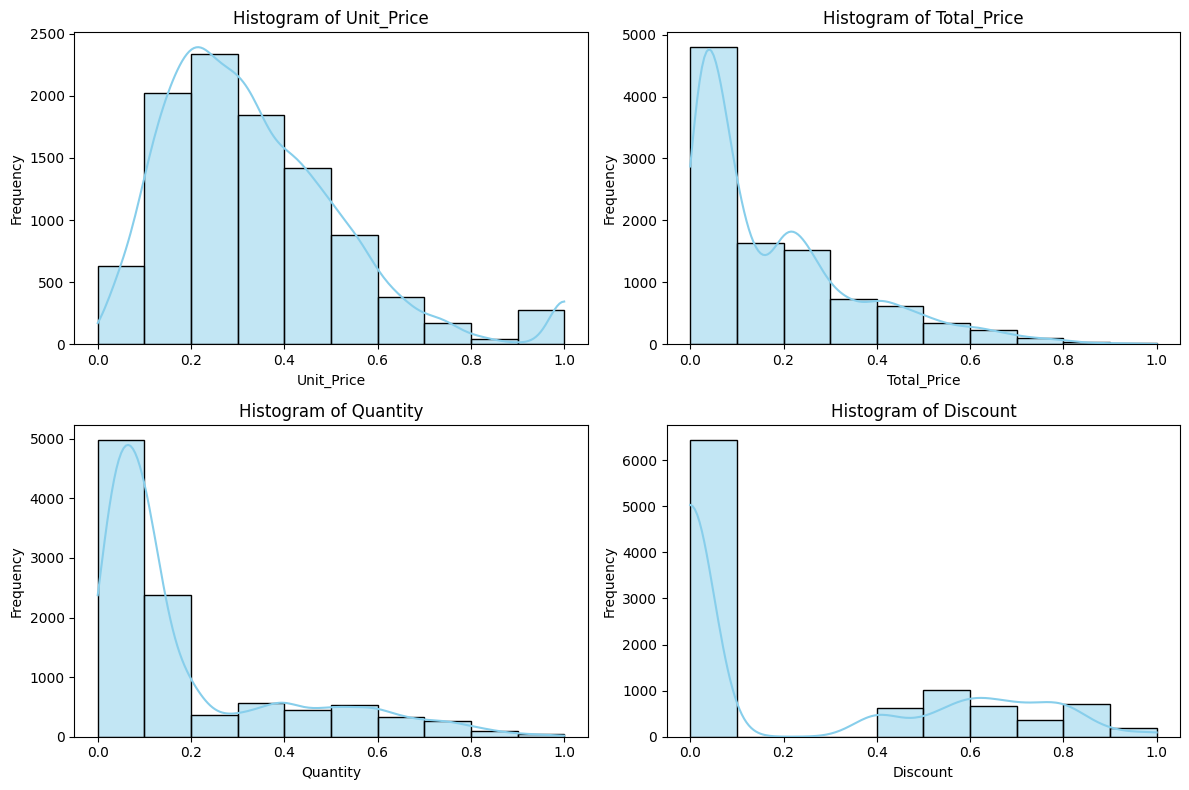

In [8]:
scaler = MinMaxScaler()
columns_to_normalize = ['Unit_Price', 'Total_Price', 'Quantity', 'Discount']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# Plot histogram
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_normalize, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=10, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Terakhir, sebelum memasuki tahap pemodelan, saya melakukan **normalisasi data** menggunakan **`MinMaxScaler`** pada kolom-kolom numerik, yaitu **`Unit_Price`, `Total_Price`, `Quantity`, dan `Discount`**. Tujuan normalisasi ini adalah untuk **menskalakan** setiap fitur numerik ke rentang [0, 1], sehingga:

1. **Rentang nilai** menjadi seragam dan tidak ada fitur yang memiliki skala jauh lebih besar dibandingkan fitur lainnya.  
2. **Algoritma pemodelan**—terutama yang sensitif terhadap skala data (misalnya *k-Nearest Neighbors* atau *Neural Networks*)—dapat bekerja lebih optimal.  

Setelah normalisasi, saya juga **memvisualisasikan histogram** untuk memeriksa distribusi data hasil normalisasi. Dengan demikian, kita bisa memastikan bahwa proses normalisasi berjalan sesuai harapan dan siap melanjutkan ke tahap pemodelan.

# **4. Data Splitting**

In [9]:
#Type your code here

X = data.drop(columns=["Customer_Segment", "Cluster"])  # Fitur
y = data["Customer_Segment"]  # Target
y_encoded = le.fit_transform(y)

Sebelum memasuki tahap pemodelan, saya memisahkan dataset menjadi **fitur (X)** dan **target (y)**. Di sini, **`Customer_Segment`** menjadi target yang akan diprediksi, sedangkan **X** berisi semua kolom lainnya. Karena **`Customer_Segment`** masih bersifat kategorikal, saya menerapkan **`LabelEncoder`** untuk mengubah nilai kategorikal menjadi nilai numerik dan menyimpannya dalam **`y_encoded`**. Langkah ini diperlukan agar model *machine learning* dapat memproses target dengan format numerik.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y , random_state=42, test_size=0.3, shuffle=True) 

Saya membagi data menjadi **data latih (X_train, y_train)** dan **data uji (X_test, y_test)** dengan proporsi 70% data latih dan 30% data uji (ditentukan oleh `test_size=0.3`). Saya juga menggunakan parameter `shuffle=True` untuk mengacak urutan data sebelum pembagian, serta `random_state=42` agar proses pembagian ini **reproducible**—sehingga jika kode dijalankan kembali, hasil pembagian akan sama.  

# **5. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [11]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


# 2. Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


# 3. Multi Layer Perceptron
mlp_model = MLPClassifier(random_state=42, max_iter=1000)  
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)


c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Masuk ke dalam tahap pemodelan klasifikasi disini saya menggunakan **tiga algoritma klasifikasi** untuk memprediksi **Customer_Segment**:

1. **Logistic Regression**  
   - Menggunakan **regresi logistik** dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Setelah proses pelatihan dengan data latih (`X_train`, `y_train`), saya menghasilkan prediksi (`y_pred_lr`) pada data uji (`X_test`).

2. **Random Forest Classifier**  
   - Model **ensemble** yang terdiri dari banyak *decision tree* dengan `n_estimators=100` dan `random_state=42`.  
   - Dilatih pada data latih, kemudian digunakan untuk memprediksi data uji (`y_pred_rf`).

3. **Multi Layer Perceptron (MLP)**  
   - **Neural Network** sederhana dengan parameter `max_iter=1000` dan `random_state=42`.  
   - Dilatih dengan data latih, dan prediksi dihasilkan untuk data uji (`y_pred_mlp`).

Dengan menggunakan ketiga model ini, saya dapat membandingkan kinerja dan memilih model yang paling baik dalam memprediksi **Customer_Segment**.

## **b. Evaluasi Model Klasifikasi**

In [12]:
#Type your code here

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")

print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")

print("MLP Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Logistic Regression
Accuracy: 0.6126666666666667
                         precision    recall  f1-score   support

High-spending Customers       0.62      0.60      0.61      1511
 Low-spending Customers       0.61      0.62      0.62      1489

               accuracy                           0.61      3000
              macro avg       0.61      0.61      0.61      3000
           weighted avg       0.61      0.61      0.61      3000



Random Forest Classifier
Accuracy: 0.999
                         precision    recall  f1-score   support

High-spending Customers       1.00      1.00      1.00      1511
 Low-spending Customers       1.00      1.00      1.00      1489

               accuracy                           1.00      3000
              macro avg       1.00      1.00      1.00      3000
           weighted avg       1.00      1.00      1.00      3000



MLP Classifier
Accuracy: 0.9773333333333334
                         precision    recall  f1-score   support

High-spend

Hasil dari ketiga model menunjukkan perbedaan signifikan dalam performa:  

1. **Logistic Regression**  
   - Mencapai akurasi sekitar **61.27%**, dengan **precision**, **recall**, dan **f1-score** yang cukup seimbang antara kedua kelas.  
   - Model ini memiliki performa yang **paling rendah** dibandingkan dua model lainnya, yang menandakan bahwa hubungan antara fitur dan target kemungkinan **tidak sepenuhnya linear** atau ada informasi yang tidak cukup ditangkap oleh model ini.  
   - Masih ada **ruang untuk perbaikan**, seperti menambahkan fitur baru atau mencoba metode regularisasi lebih lanjut.  

2. **Random Forest Classifier**  
   - Mencapai **akurasi hampir sempurna (99.9%)**, dengan precision, recall, dan f1-score yang **hampir 1.00** di semua metrik.  
   - Performa yang **sangat tinggi** ini menunjukkan bahwa model mampu menangkap pola dalam data dengan sangat baik. Namun, perlu diperhatikan bahwa:  
     - Jika dataset terlalu kecil atau terlalu mudah diprediksi, model bisa menjadi terlalu “menghafal” data latih, sehingga **performa di data baru perlu diuji lebih lanjut**.  
     - Kemungkinan **overfitting** harus dicek dengan dataset yang benar-benar berbeda atau dengan validasi yang lebih ketat.  

3. **MLP Classifier**  
   - Mencapai akurasi **97.73%**, dengan **precision** dan **recall** yang seimbang antara kelas **High-Spending** dan **Low-Spending Customers**.  
   - Performa ini menunjukkan bahwa model dapat mengenali pola kompleks dalam data dengan baik, meskipun masih sedikit lebih rendah dibandingkan Random Forest.  
   - Meskipun hasilnya sangat tinggi, masih perlu diuji dengan data baru untuk melihat apakah model benar-benar mampu **menggeneralisasi** atau hanya “menghafal” pola tertentu.  



### Kesimpulan  
- **Logistic Regression** memberikan hasil **paling rendah**, yang bisa jadi karena keterbatasannya dalam menangkap hubungan kompleks dalam data.  
- **Random Forest dan MLP** menunjukkan hasil yang sangat tinggi, dengan **Random Forest hampir sempurna (99.9%)**, yang bisa mengindikasikan **kemungkinan overfitting** atau dataset yang terlalu mudah diprediksi.  
- **Pengecekan lebih lanjut diperlukan**, terutama pada model dengan akurasi tinggi, untuk memastikan apakah mereka benar-benar memiliki kemampuan **generalisasi** terhadap data yang belum pernah mereka lihat sebelumnya.  

## **c. Tuning Model Klasifikasi (Optional)**

In [13]:
#Type your code here

# 1. Logistic Regression dengan GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # untuk l1 gunakan solver liblinear
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)


# 2. Random Forest Classifier dengan RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rand_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                             param_distributions=param_dist_rf,
                             n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rand_rf.fit(X_train, y_train)



from sklearn.model_selection import GridSearchCV

# Contoh parameter grid
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (50, 50), (100,)],   # Contoh variasi layer
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive']
}

mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=1000),
    param_grid_mlp,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)

mlp_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (50, 50), (100,)],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['adam', 'sgd']},
             scoring='accuracy')

Selanjutnya, saya kembali menerapkan **tiga algoritma** tersebut (**Logistic Regression**, **Random Forest**, dan **MLP**) namun dengan **strategi hyperparameter tuning**. Tujuannya adalah untuk mencari kombinasi parameter yang **optimal**, sehingga kinerja model dapat meningkat. Berikut pendekatan yang dilakukan:

1. **Logistic Regression (GridSearchCV)**  
   - Saya menggunakan **GridSearchCV** dengan beberapa variasi parameter seperti `C`, `penalty`, dan `solver`.  
   - **GridSearchCV** akan mencoba semua kombinasi parameter dalam `param_grid_lr` menggunakan *k-fold cross-validation*, lalu memilih kombinasi dengan **akurasi** terbaik.

2. **Random Forest Classifier (RandomizedSearchCV)**  
   - Untuk **Random Forest**, saya memanfaatkan **RandomizedSearchCV**, di mana parameter seperti `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, dan `bootstrap` di-*sampling* secara acak dari daftar yang ditentukan.  
   - **RandomizedSearchCV** lebih efisien daripada GridSearchCV ketika ruang parameter cukup besar, karena tidak mencoba semua kombinasi melainkan **hanya sejumlah iterasi** (ditentukan oleh `n_iter`).

3. **MLPClassifier (GridSearchCV)**  
   - Untuk **MLP**, saya kembali menggunakan **GridSearchCV** dengan variasi parameter `hidden_layer_sizes`, `activation`, `solver`, dan `learning_rate`.  
   - Prosesnya serupa dengan Logistic Regression, yaitu memeriksa semua kombinasi parameter lalu memilih yang terbaik berdasarkan **akurasi**.

Dengan cara ini, setiap model berpeluang menunjukkan performa maksimal setelah melalui pencarian parameter terbaik, dibandingkan dengan penggunaan parameter default.

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

In [14]:
#Type your code here

print("Best parameters for Logistic Regression:", grid_lr.best_params_)
y_pred_lr = grid_lr.predict(X_test)
print("Logistic Regression Accuracy After Tuning:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("\n")



print("Best parameters for Random Forest:", rand_rf.best_params_)
y_pred_rf = rand_rf.predict(X_test)
print("Random Forest Accuracy After Tuning:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\n")


print("Best parameters for MLP:", mlp_grid.best_params_)
y_pred_mlp_tuned = mlp_grid.predict(X_test)
print("MLP Accuracy After Tuning:", accuracy_score(y_test, y_pred_mlp_tuned))
print(classification_report(y_test, y_pred_mlp_tuned))


Best parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Logistic Regression Accuracy After Tuning: 0.64
                         precision    recall  f1-score   support

High-spending Customers       0.64      0.64      0.64      1511
 Low-spending Customers       0.64      0.64      0.64      1489

               accuracy                           0.64      3000
              macro avg       0.64      0.64      0.64      3000
           weighted avg       0.64      0.64      0.64      3000



Best parameters for Random Forest: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None, 'bootstrap': True}
Random Forest Accuracy After Tuning: 0.999
                         precision    recall  f1-score   support

High-spending Customers       1.00      1.00      1.00      1511
 Low-spending Customers       1.00      1.00      1.00      1489

               accuracy                           1.00      3000
              macro av

Berdasarkan hasil tuning di atas, dapat kita lihat bahwa:


1. **Logistic Regression**  
   - Setelah proses tuning dengan kombinasi parameter terbaik (`C=0.01`, `penalty='l2'`, `solver='lbfgs'`), akurasi mencapai **0.64**.  
   - Meskipun nilainya tidak terlalu tinggi, terjadi **peningkatan** jika dibandingkan dengan performa sebelum tuning (sekitar **0.61**).  
   - Peningkatan ini menunjukkan bahwa penyesuaian **hyperparameter** mampu sedikit memperbaiki kemampuan model untuk menangkap pola data.

2. **Random Forest**  
   - Dengan parameter terbaik (`n_estimators=50`, `min_samples_split=2`, `min_samples_leaf=4`, `max_depth=None`, `bootstrap=True`), model ini mencapai **akurasi 0.999**.  
   - **Hampir sempurna** di semua metrik (precision, recall, f1-score).  
   - Hasil ini perlu ditinjau lebih lanjut, misalnya dengan melakukan **validasi tambahan** atau **mengecek data uji baru**, karena akurasi yang mendekati 100% sering menandakan bahwa data mungkin sangat mudah diprediksi atau ada potensi **overfitting**.

3. **MLPClassifier**  
   - Setelah tuning dengan parameter (`activation='tanh'`, `hidden_layer_sizes=(50, 50)`, `learning_rate='constant'`, `solver='adam'`), akurasi mencapai **1.0**.  
   - Ini berarti model **sempurna** dalam memprediksi kelas **High-spending** dan **Low-spending** pada data uji.  
   - Seperti halnya Random Forest, hasil yang **terlalu sempurna** memerlukan **verifikasi lebih lanjut** untuk memastikan tidak terjadi **overfitting** atau data yang terlalu sederhana.

### Kesimpulan

- **Logistic Regression** mengalami **peningkatan moderat** setelah tuning, namun performanya masih di bawah dua model lainnya.  
- **Random Forest** dan **MLP** menunjukkan **hasil sangat tinggi** hingga mendekati/sempurna, yang perlu diwaspadai karena berpotensi **overfitting** atau disebabkan oleh **karakteristik dataset** yang mudah diprediksi.  
- Langkah selanjutnya adalah melakukan **validasi lebih mendalam**, misalnya:
  - Mencoba **cross-validation** dengan lebih banyak fold,  
  - Menggunakan **data uji baru** yang berbeda,  
  - Atau menambah kompleksitas dataset,  
  untuk memastikan model dapat **benar-benar menggeneralisasi** di luar data latih.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

## 1. Apakah Hasil Setelah Tuning Lebih Baik



- **Logistic Regression**  
  - **Sebelum tuning:** Akurasi sekitar **61%**, dengan precision, recall, dan f1-score yang cukup berimbang, namun tergolong rendah dibanding model lain.  
  - **Setelah tuning:** Akurasi meningkat menjadi **64%**. Terjadi sedikit perbaikan pada nilai precision, recall, serta f1-score untuk kedua kelas.  
  - **Kesimpulan:** Proses tuning **memberikan dampak positif**, meski peningkatannya tidak terlalu besar.

- **Random Forest**  
  - **Sebelum tuning:** Sudah menunjukkan **akurasi sangat tinggi**, yaitu **99.9%**, dengan metrik evaluasi lainnya yang juga hampir sempurna.  
  - **Setelah tuning:** Tetap mencapai akurasi **99.9%**, sehingga tidak terlihat peningkatan berarti karena model memang sudah **sangat optimal** sejak awal.  
  - **Kesimpulan:** Tuning tidak mengubah performa karena model sudah mendekati **performa sempurna** sebelum tuning.

- **MLP Classifier**  
  - **Sebelum tuning:** Akurasi sekitar **97.7%**, dengan precision, recall, dan f1-score yang sudah tinggi.  
  - **Setelah tuning:** Mencapai **akurasi 100%**, menjadikan model **sempurna** di data uji.  
  - **Kesimpulan:** Terjadi **peningkatan signifikan** dari performa yang sudah tinggi menjadi **benar-benar sempurna**, namun hal ini perlu dicek lebih lanjut untuk memastikan tidak terjadi **overfitting**.


Secara keseluruhan, **Logistic Regression** mengalami peningkatan setelah tuning, sedangkan **Random Forest** sudah hampir sempurna sejak awal, sehingga tuning tidak banyak mengubah performanya. **MLP** bahkan mencapai akurasi sempurna setelah tuning, menandakan perlu adanya verifikasi lebih lanjut untuk memastikan kemampuan generalisasi model.

## 2. Berdasarkan Akurasi yang di Dapatkan Apakah Model mengalami Overfitting

Cross-Validation Accuracy Scores: [1.         0.99928571 1.         1.         0.99928571]
Rata-rata CV Accuracy: 0.9997142857142858


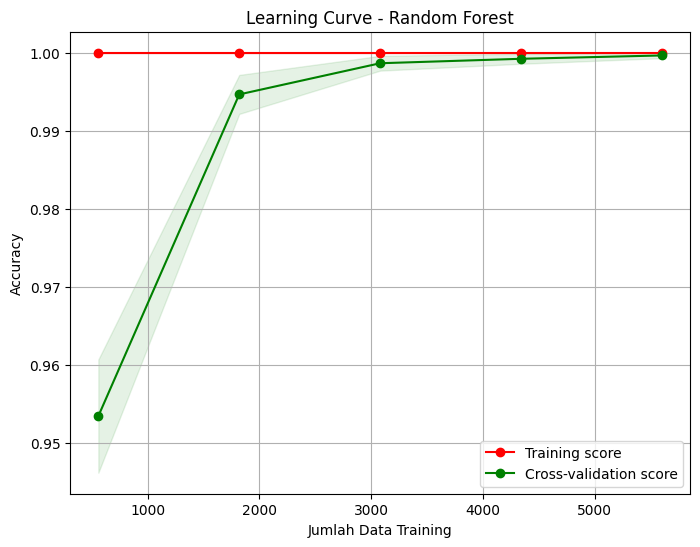

In [15]:
# Contoh: menggunakan Random Forest sebagai model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Rata-rata CV Accuracy:", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
plt.title('Learning Curve - Random Forest')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan ini untuk mengevaluasi apakah pemodelan dengan **Random Forest** mengalami overfitting dengan menggunakan **cross-validation** dan melihat **learning curve**.  

Dari hasil yang ditunjukkan dalam gambar dan nilai cross-validation:  

1. **Nilai cross-validation accuracy** sangat tinggi, dengan skor rata-rata **0.9997** dan hanya sedikit fluktuasi antara fold.  
2. **Learning curve** menunjukkan **training score** (garis merah) tetap di angka **1.0**, sedangkan **cross-validation score** (garis hijau) meningkat pesat dengan bertambahnya jumlah data hingga mencapai hampir **1.0**, tanpa adanya celah yang berarti antara keduanya.  
3. **Kurva validasi** juga menunjukkan **confidence interval yang sangat kecil**, menandakan bahwa model memiliki performa yang sangat stabil di berbagai subset data validasi.  

### Analisis dan Interpretasi:  
- **Tidak ada indikasi overfitting** yang biasanya terlihat dari adanya gap antara training score dan cross-validation score. Dalam hal ini, kedua skor hampir sama.  
- Namun, **akurasi yang terlalu tinggi (hampir 1.0 di semua fold)** bisa menjadi tanda bahwa dataset mungkin terlalu mudah diprediksi atau model telah menangkap pola yang sangat spesifik.  
- **Kemungkinan model "menghafal" pola data** masih perlu diuji dengan dataset yang benar-benar berbeda atau lebih kompleks.  

Kesimpulannya, **tidak ada indikasi overfitting dari learning curve dan cross-validation**, tetapi hasil yang **terlalu sempurna** perlu diverifikasi lebih lanjut agar model benar-benar dapat digunakan untuk generalisasi di dunia nyata.

c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\FX506\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-Validation Accuracy Scores (MLP): [0.98285714 0.745      0.79571429 0.97214286 0.9       ]
Rata-rata CV Accuracy (MLP): 0.8791428571428572


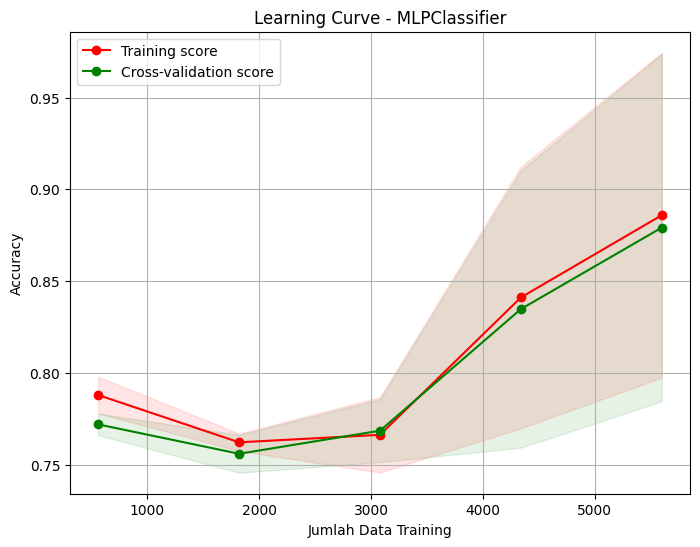

In [16]:
mlp_model = MLPClassifier(random_state=42, max_iter=1000)

# 1. Cross Validation
# Menggunakan 5-fold cross validation pada data training
cv_scores = cross_val_score(mlp_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores (MLP):", cv_scores)
print("Rata-rata CV Accuracy (MLP):", np.mean(cv_scores))

# 2. Learning Curve
# Menggunakan learning_curve untuk mendapatkan performance model pada berbagai ukuran data training
train_sizes, train_scores, validation_scores = learning_curve(
    mlp_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Hitung rata-rata dan standar deviasi untuk training dan validasi
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.1,
    color="r"
)
plt.plot(train_sizes, validation_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(
    train_sizes,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.1,
    color="g"
)
plt.title('Learning Curve - MLPClassifier')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Saya melakukan ini untuk mengetahui apakah pemodelan dengan **Multi-Layer Perceptron (MLP)** mengalami overfitting atau tidak. Oleh sebab itu, saya menggunakan **cross-validation** dan melihat **learning curve**. Dari hasil yang ditunjukkan:

1. **Nilai cross-validation accuracy** bervariasi pada setiap fold, yaitu `[0.98285714, 0.745, 0.79571429, 0.97214286, 0.9]`, dengan **rata-rata 0.879**.  
2. **Learning curve** (pada gambar) menunjukkan **training score** yang meningkat seiring bertambahnya jumlah data, dan **cross-validation score** juga turut naik dengan tren yang mirip. Meski terdapat fluktuasi (area hijau cukup lebar), tidak tampak **gap** yang ekstrem antara keduanya.

Berdasarkan kedua hal tersebut, tidak terlihat indikasi **overfitting** yang jelas—**training score** dan **cross-validation score** sama-sama berada pada kisaran yang cukup tinggi tanpa selisih mencolok. Namun, variasi skor cross-validation yang cukup lebar menandakan bahwa performa MLP dapat berubah tergantung pada pembagian data latih dan validasi.

Berdasarkan hasil **cross-validation** dan **learning curve**, baik **Multi-Layer Perceptron (MLP)** maupun **Random Forest** tidak menunjukkan **indikasi overfitting** yang jelas—training score dan cross-validation score berada pada rentang yang sama tanpa gap signifikan. Namun, **akurasi yang mendekati atau mencapai 1.0** secara konsisten mengisyaratkan bahwa:  

1. **Dataset kemungkinan terlalu mudah diprediksi** atau jumlah datanya **terlalu sedikit**, sehingga model dapat “menghafal” pola data dengan mudah.  
2. **Akurasi sempurna jarang terjadi di dunia nyata**, sehingga hasil ini perlu **diverifikasi lebih lanjut** dengan:  
   - **Data uji terpisah** atau **data baru**,  
   - **Repeated cross-validation** untuk menguji konsistensi,  
   - Penambahan **kompleksitas dataset** atau **lebih banyak data**.  

Dengan demikian, meskipun **tidak ada tanda overfitting** berdasarkan kurva metrik dan cross-validation, **tingkat akurasi yang terlalu tinggi** tetap perlu diwaspadai. Model memang belum terbukti overfitting, tetapi kita perlu memastikan kemampuannya benar-benar **generalisasi** di luar data yang sudah dikenal.

## 3. Rekomendasi apa yang anda berika untuk next pemodelannya

Menurut saya untuk **Rekomendasi ke Tahap Pemodelan Selanjutnya** ada beberapa diantaranya yaitu: 

1. **Mengumpulkan atau Menggunakan Lebih Banyak Data**  
   - Dengan data yang lebih banyak, model akan lebih menantang untuk “menghafal” pola secara sempurna dan dapat menghasilkan evaluasi yang lebih realistis.

2. **Menggunakan Metode Validasi yang Lebih Beragam**  
   - Selain cross-validation standar, Anda dapat mencoba *repeated cross-validation* atau *stratified k-fold cross-validation* untuk memastikan hasil benar-benar konsisten.

3. **Menggukur Kinerja dengan Metrik Tambahan**  
   - Selain akurasi, pertimbangkan metrik seperti *precision, recall, F1-score*, atau *AUC-ROC* untuk mendapatkan gambaran kinerja model yang lebih menyeluruh.

4. **Mengecek Distribusi dan Kompleksitas Fitur**  
   - Pastikan data yang digunakan cukup variatif dan tidak terlalu mudah diprediksi. Jika perlu, pertimbangkan untuk menambah fitur baru yang relevan atau melakukan *feature engineering*.

5. **Evaluasi di Data atau Lingkungan Nyata**  
   - Uji model di data uji (test set) yang benar-benar terpisah atau data baru (jika memungkinkan) untuk memastikan performa tidak hanya tinggi di data yang sudah dikenal.

6. **Mempertimbangkan Regularisasi atau Penyesuaian Arsitektur Model**  
   - Untuk model MLP, Anda bisa mencoba *early stopping*, *dropout*, atau menyesuaikan jumlah neuron dan lapisan agar tidak terlalu kompleks untuk dataset yang relatif kecil.  
   - Untuk Random Forest, Anda bisa menyesuaikan *max_depth* atau parameter lain yang membatasi kompleksitas pohon.

Dengan langkah-langkah tersebut, Anda dapat memastikan bahwa model tidak hanya mencapai akurasi tinggi di dataset terbatas, tetapi juga benar-benar memiliki kemampuan generalisasi yang baik.